<div align='right'>
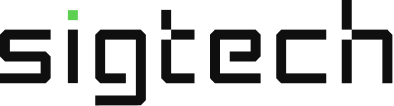
</div>

# Bond Futures Demo

- Environment
- Objects
- Building Blocks
- Example Strategies

___

## Environment

In [1]:
import datetime as dtm
import pandas as pd
import numpy as np

In [2]:
import sigtech.framework as sig

env = sig.init()

SigTech environment successfully initialized


___

## Objects

There are three fundamental objects in the platform:
- **Tradable instruments**: instruments, tradable on the financial markets,
- (Tradable) **Strategies**: a set of rules and logic to buy or sell tradable instruments over time,
- **Non-tradable data**: objects that are used for signalling purposes or research like macro-economic data.
<br>

<div align='center'>
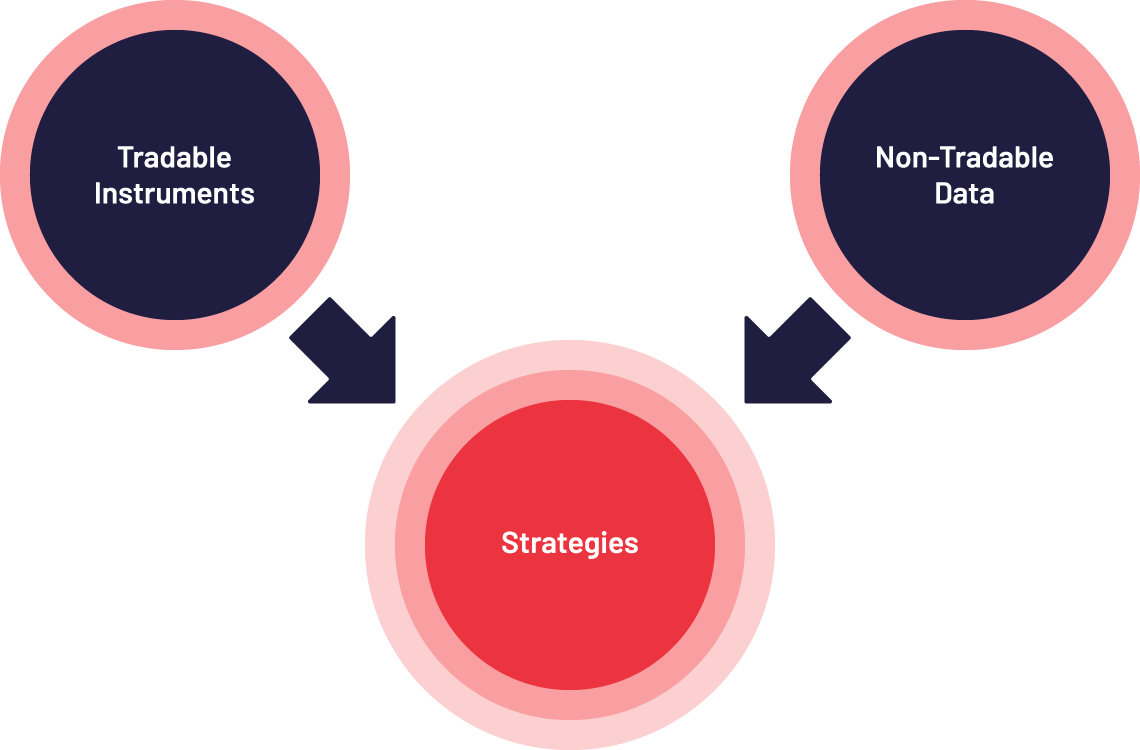
</div>


In [3]:
sig.obj.get("EURUSD CURNCY")

EURUSD CURNCY <class 'sigtech.framework.instruments.fixes.FXFix'>[139697904880512]

In [4]:
future = sig.obj.get("TYH23 COMDTY")
future

TYH23 COMDTY <class 'sigtech.framework.instruments.futures.BondFuture'>[139697987449280]

In [5]:
future?

Type:           BondFuture
String form:    TYH23 COMDTY <class 'sigtech.framework.instruments.futures.BondFuture'>[139697987449280]
File:           /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/instruments/futures.py
Docstring:     
Class representing bond future instrument.

Example object creation:

::

    future = BondFuture(
        contract_code='TY',
        contract_size=100000,
        currency='USD',
        ticker='TYZ18',
        exchange_code='CBOTFCF(T) EXCHANGE GROUP',
        expiry_date_stored='2018-12-19',
        first_delivery_date='2018-12-03',
        first_delivery_notice_date='2018-11-30',
        futvalpt_raw='1000.00',
        last_delivery_date='2018-12-31'
    )
Init docstring: Method generated by attrs for class BondFuture.

In [6]:
future.info()

{'product_type': 'Bond Future',
 'currency': 'USD',
 'ticker': 'TYH23',
 'contract_code': 'TY',
 'contract_sector': 'COMDTY',
 'group_name': 'TY COMDTY FUTURES GROUP',
 'expiry_date': datetime.date(2023, 3, 22),
 'first_delivery_notice_date': datetime.date(2023, 2, 28)}

In [7]:
future.data_dict()

{'_product_type': 'Bond Future',
 'instrument_id': None,
 '_data_source_all': ['SIG'],
 '_available_data_points': ['EOD'],
 '_default_data_point': 'EOD',
 'price_factor': 1.0,
 'use_price_factor': True,
 'intraday_times': [],
 'intraday_tz_str': 'UTC',
 'currency': 'USD',
 'ticker': 'TYH23',
 'db_ticker': None,
 'db_sector': 'COMDTY',
 '_exchange_code': 'CMX(T) EXCHANGE GROUP',
 'description': '',
 'expiry_date_stored': datetime.date(2023, 3, 22),
 'first_delivery_notice_date_stored': None,
 'futvalpt_raw': 1000.0,
 'contract_size': 100000.0,
 'tick_size': 0.015625,
 'first_delivery_date': None,
 'last_delivery_date': None,
 'first_trade_date': None,
 'activity_fields': ['Volume', 'OpenInterest'],
 'contract_code': 'TY',
 'group_name': 'TY COMDTY FUTURES GROUP'}

In [8]:
future.history_fields

['AskPrice',
 'BidPrice',
 'LastPrice',
 'data_point',
 'HighPrice',
 'LowPrice',
 'MidPrice',
 'OpenPrice',
 'open_interest',
 'Volume',
 'QuotedAskPrice',
 'QuotedBidPrice',
 'QuotedLastPrice',
 'QuotedHighPrice',
 'QuotedLowPrice',
 'QuotedMidPrice',
 'QuotedOpenPrice']

In [9]:
future.history().tail()

2023-03-16    113.656250
2023-03-17    115.125000
2023-03-20    114.593750
2023-03-21    113.640625
2023-03-22    113.718750
Name: (LastPrice, EOD, TYH23 COMDTY), dtype: float64

In [10]:
future.intraday_history().tail()

trading_datetime
2023-03-22 15:14:00+00:00    113.718750
2023-03-22 15:16:00+00:00    113.718750
2023-03-22 15:17:00+00:00    113.781250
2023-03-22 15:18:00+00:00    113.765625
2023-03-22 15:22:00+00:00    113.421875
Name: (LastPrice, TYH23 COMDTY), dtype: float64

<AxesSubplot:>

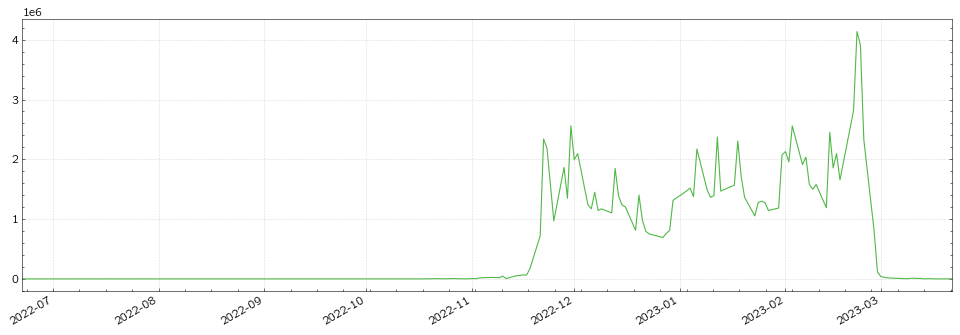

In [11]:
future.history(field="Volume").plot()

<AxesSubplot:>

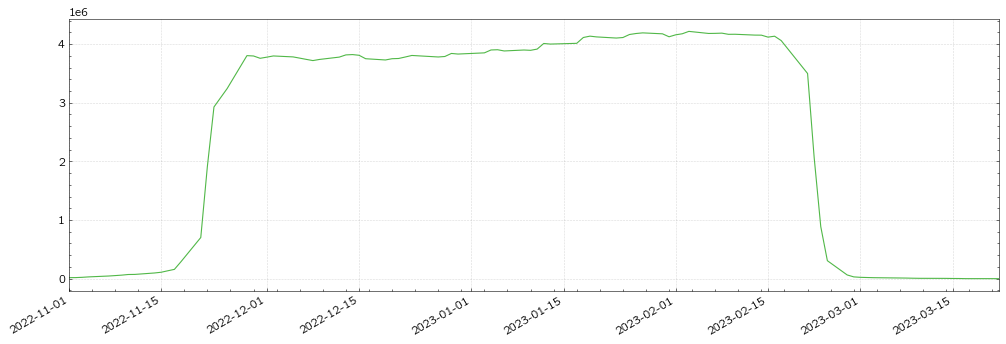

In [12]:
future.history("open_interest")["2022-11-01":].plot()

In [13]:
future.ctd(dtm.date.today())

'US 4 2030/02/28 GOVT'

In [14]:
future.ctd_data()

,value,conversion_factor,symbology
trading_datetime,,,
2022-06-22,US912828YS30,0.7740,ISIN
2022-06-23,US912828YS30,0.7740,ISIN
2022-06-24,US912828YS30,0.7740,ISIN
2022-06-25,US912828YS30,0.7740,ISIN
2022-06-26,US912828YS30,0.7740,ISIN
...,...,...,...
2023-03-19,US91282CFT36,0.8937,ISIN
2023-03-20,US91282CFT36,0.8937,ISIN
2023-03-21,US91282CFT36,0.8937,ISIN


### Groups

In [15]:
ty_grp = sig.obj.get("TY COMDTY FUTURES GROUP")
ty_grp

TY COMDTY FUTURES GROUP <class 'sigtech.framework.instruments.futures.FuturesContractGroup'>[139697891153472]

In [16]:
ty_grp.info()

2023-04-21 05:50:01,800 [461] [sigtech.framework.internal.utils.deprecation] WARNING: Call to deprecated function 'exchange_open' from /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/instruments/futures.py:526. Use `exchange_open_on_day` instead. 'exchange_open' will be removed in framework v9.


{'product_type': 'Futures Contract Group',
 'item_product_type': 'Bond Future',
 'contract_code': 'TY',
 'contract_sector': 'COMDTY',
 'asset_description': 'US 10YR NOTE',
 'underlying_index_ticker': '',
 'first_contract': 'TYM00 COMDTY',
 'contract_size': 100000.0,
 'tick_size': 0.015625,
 'contract_month_codes': ['H', 'M', 'U', 'Z'],
 'data_source_all': ['CSI'],
 'default_data_point': 'EOD',
 'currency': 'USD',
 'exchange_code': 'CMX(T) EXCHANGE GROUP',
 'exchange_open': datetime.time(9, 0),
 'exchange_close': datetime.time(16, 30),
 'timezone': 'America/Chicago',
 'holidays': 'CME_INTEREST_RATES_FLOOR(T) CALENDAR',
 'settlement_time': datetime.time(14, 0),
 'yield_quoted': False}

In [17]:
ty_grp.contract_names(start=dtm.date(2015, 1, 1), end=dtm.date(2017, 1, 1))

['TYH15 COMDTY',
 'TYM15 COMDTY',
 'TYU15 COMDTY',
 'TYZ15 COMDTY',
 'TYH16 COMDTY',
 'TYM16 COMDTY',
 'TYU16 COMDTY',
 'TYZ16 COMDTY',
 'TYH17 COMDTY']

In [18]:
ty_grp.active_contract()

TYM23 COMDTY <class 'sigtech.framework.instruments.futures.BondFuture'>[139697838322832]

In [19]:
ty_grp.session_data().tail(3)

,country,iso_code,mic_code,exchange,product,type,code,calendar_start,calendar_end,day_start,...,notes,standard_time,dst,dst_starts,dst_ends,olson_time_zone,filename,created_at,data_provider,internal_id
56,United States,US,XCBT-CME,CBOT Financial Contracts (Electronic Trading),10-Year U.S. Treasury Note Futures,Standard Derivative,ZN,2024-01-01,NaT,Monday,...,NaN,-6:00,-5:00,12-Mar-2023 02:00:00,05-Nov-2023 02:00:00,America/Chicago,s3://market-data.eu-west-1.prod.sigtech.ninja/...,2023-03-18 05:00:39.826,COPP_CLARK,TY COMDTY FUTURES GROUP
57,United States,US,XCBT-CME,CBOT Financial Contracts (Electronic Trading),10-Year U.S. Treasury Note Futures,Standard Derivative,ZN,2024-01-15,NaT,Monday,...,NaN,-6:00,-5:00,12-Mar-2023 02:00:00,05-Nov-2023 02:00:00,America/Chicago,s3://market-data.eu-west-1.prod.sigtech.ninja/...,2023-03-18 05:00:39.826,COPP_CLARK,TY COMDTY FUTURES GROUP
58,United States,US,XCBT-CME,CBOT Financial Contracts (Electronic Trading),10-Year U.S. Treasury Note Futures,Standard Derivative,ZN,2024-02-19,NaT,Monday,...,NaN,-6:00,-5:00,12-Mar-2023 02:00:00,05-Nov-2023 02:00:00,America/Chicago,s3://market-data.eu-west-1.prod.sigtech.ninja/...,2023-03-18 05:00:39.826,COPP_CLARK,TY COMDTY FUTURES GROUP


___

## Building Blocks

Within the SigTech platform, the user has the ability to use **Building Blocks**, a set of pre-built methods designed to speed up the process of creating basic strategies.

`RollingFutureStrategy` is the building block for most of the future based strategies.
The strategy is constructed with a number of rolling rules which tell the strategy how to roll into the next contract. 
The rolling rules provide the following information:
* When to roll (for example, n days before expiry).
* What contract to enter next.
* Over how many days to roll.

In [20]:
sig.RollingFutureStrategy??

Init signature:
sig.RollingFutureStrategy(
    *,
    cache: Optional[bool] = True,
    identifier: Optional[sigtech.framework.infra.data_adapter.identifier.Identifier] = None,
    env: Optional[sigtech.framework.config.config.ConfiguredEnvironment] = NOTHING,
    product_type: Optional[str] = None,
    instrument_id: Optional[int] = None,
    data_source_all: Optional[list] = NOTHING,
    available_data_points: Optional[list] = NOTHING,
    default_data_point: Optional[sigtech.framework.infra.data_adapter.common.DataPoint] = 'EOD',
    price_factor: float = 1.0,
    use_price_factor: Optional[bool] = True,
    intraday_times: Optional[list] = NOTHING,
    intraday_tz_str: Optional[str] = 'UTC',
    ticker: Optional[str] = None,
    db_ticker: Optional[str] = None,
    db_sector: Optional[str] = None,
    initial_cash: Optional[float] = 1000.0,
    strategy_sizing_quantity: Optional[float] = None,
    start_date: Optional[datetime.date] = None,
    end_date: Optional[datetime.date] = d

In [21]:
ty_rolling = sig.RollingFutureStrategy(
    currency="USD",
    start_date=dtm.date(2010, 1, 4),
    contract_code="TY",
    contract_sector="COMDTY",
    rolling_rule="front",
    front_offset="-2:-1",
)

<AxesSubplot:>

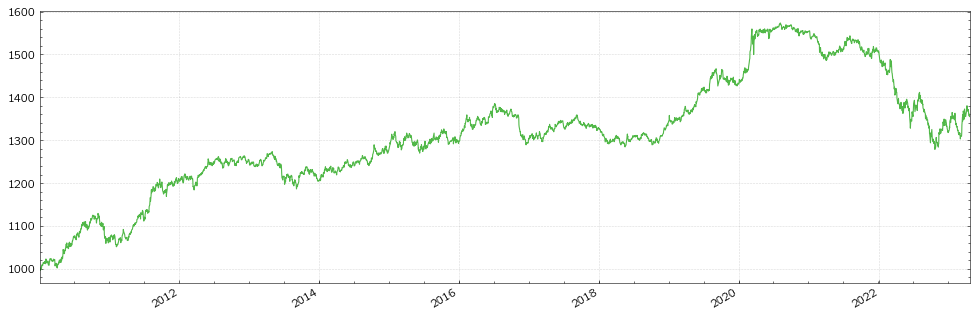

In [22]:
ty_rolling.history().plot()

In [23]:
ty_rolling.price_series().tail()

2023-04-17    114.359375
2023-04-18    114.484375
2023-04-19    114.187500
2023-04-20    114.656250
2023-04-21    114.656250
dtype: float64

In [24]:
ty_rolling.plot.timeline()

In [25]:
ty_rolling.plot.portfolio_table("TOP_ORDER_PTS", start_dt=dtm.date(2022, 9, 14))

In [26]:
ty_rolling.implied_roll_yield().tail()

2023-04-17   -0.025757
2023-04-18   -0.025729
2023-04-19   -0.025796
2023-04-20   -0.026237
2023-04-21   -0.026237
dtype: float64

In [27]:
ty_rolling.spot_dv01??

Signature: ty_rolling.spot_dv01()
Source:   
    def spot_dv01(self):
        """ Returns a Series of spot_dv01 values for the underlying future that is currently part of the index """
        # Build and get the underlying weights
        self.build()
        hist = self.history()
        positions = self.inspect.bottom_positions_df(tzinfo=pytz.utc, unit_type='TRADE')
        positions_eod = positions[positions.index.tz_convert(self.valuation_tzinfo).time == self.valuation_time].copy()
        positions_eod.index = positions_eod.index.floor('1D').tz_convert(None)
        positions_eod.reindex(hist.index, method='ffill')

        # load dependencies
        future_objs = [f for f in self.env.object.get_many(positions_eod.columns)
                       if isinstance(f, (BondFuture, InterestRateFuture))]
        if len(future_objs) == 0:
            raise NotImplementedError('Spot DV01 calculation is only supported for BondFuture and InterestRateFuture')
        deps = list(itertools.ch

___

## Example Strategy: Carry

Implied roll yield is the difference between the current futures price and the expected spot price of the underlying asset at the futures contract's expiration. In the context of bond futures, a higher implied roll yield indicates a more attractive carry opportunity, as it suggests the futures contract is trading at a discount relative to the expected spot price at expiration.

By going long on high implied roll yield bond futures and short on low implied roll yield bond futures, you are essentially exploiting the interest rate differentials and term structure of the bond futures market, which is a carry trade strategy.

- Calculate implied roll yields: For each bond future in your investment universe across different countries, calculate the implied roll yield. This can be derived from the term structure of the bond futures, which reflects the market's expectations of future interest rates.

- Rank the bond futures: Rank the bond futures based on their implied roll yields, from highest to lowest.

- Select long/short positions: Go long on the top 20% of bond futures with the highest implied roll yields and go short on the bottom 20% with the lowest implied roll yields.

- Rebalance periodically: Monitor the positions and rebalance the portfolio periodically, adjusting the long/short positions based on changes in the bond futures' implied roll yields.

In [28]:
from sigtech.framework.default_strategy_objects.rolling_futures import *
from sigtech.framework.default_strategy_objects.rolling_futures_fx_hedged import *

In [30]:
universe = [
    ty_comdty_front(),
    fv_comdty_front(),
    us_comdty_front(),
    tu_comdty_front(),
    usd_cn_comdty_front(),
    usd_g_comdty_front(),
    usd_jb_comdty_front(),
    usd_jb_comdty_front(),
    usd_xm_comdty_front(),
]

In [31]:
implied_roll_yields = pd.DataFrame({x.name: x.implied_roll_yield() for x in universe})
implied_roll_yields.tail()

,USD TY COMDTY LONG FRONT RF STRATEGY,USD FV COMDTY LONG FRONT RF STRATEGY,USD US COMDTY LONG FRONT RF STRATEGY,USD TU COMDTY LONG FRONT RF STRATEGY,USD CN COMDTY LONG FRONT RF STRATEGY,USD G COMDTY LONG FRONT RF STRATEGY,USD JB COMDTY LONG FRONT RF STRATEGY,USD XM COMDTY LONG FRONT RF STRATEGY
2023-04-17,-0.025757,-0.019531,-0.003864,-0.024193,-0.043601,0.011043,0.022593,0.0
2023-04-18,-0.025729,-0.019520,-0.003856,-0.022524,-0.043500,0.011095,0.023940,0.0
2023-04-19,-0.025796,-0.019559,-0.004831,-0.022860,-0.043552,0.012038,0.023400,0.0
2023-04-20,-0.026237,-0.020640,-0.004809,-0.022819,-0.043298,0.011953,0.023389,0.0
2023-04-21,-0.026237,-0.020640,-0.004809,-0.022819,-0.043298,0.011953,0.023389,0.0


In [32]:
carry_strategy = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 22),
    signal_name=sig.signal_library.from_ts(implied_roll_yields).name,
    rebalance_frequency="1W-FRI",
    allocation_function=sig.signal_library.allocation.long_short_dollar_neutral,
    allocation_kwargs={"proportion": 0.2},
    ticker="BOND FUTURES CARRY",
)

<AxesSubplot:>

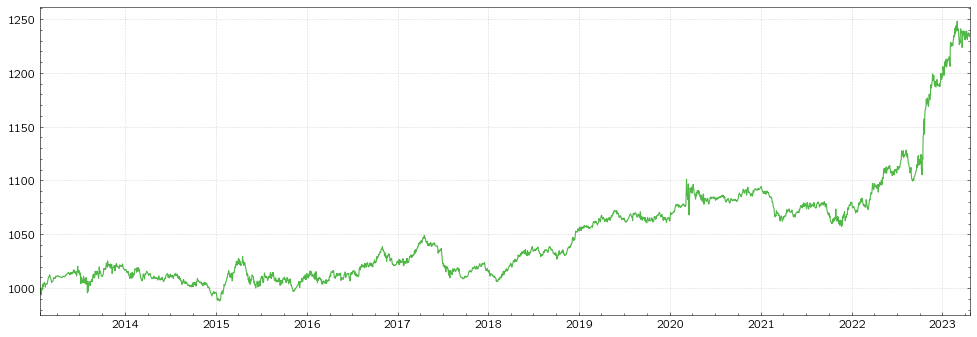

In [33]:
carry_strategy.history().plot()

In [34]:
carry_strategy.plot.timeline()

___

## Example Strategy: Intraday Signal Strategy

In [35]:
from sigtech.framework.default_strategy_objects.rolling_bonds import usd_10y_on_the_run

In [36]:
ust_cal = sig.obj.get("US_GOVT_AUC_10Y CALENDAR")

In [37]:
ust_cal.calendar_days[-10:]

[datetime.date(2023, 8, 9),
 datetime.date(2023, 9, 13),
 datetime.date(2023, 10, 11),
 datetime.date(2023, 11, 8),
 datetime.date(2023, 12, 13),
 datetime.date(2024, 1, 10),
 datetime.date(2024, 2, 7),
 datetime.date(2024, 3, 13),
 datetime.date(2024, 4, 10),
 datetime.date(2024, 5, 8)]

In [38]:
entry_df = pd.DataFrame(
    {ty_comdty_front().name: 1, usd_10y_on_the_run().name: -1},
    index=[dtm.datetime.combine(x, dtm.time(9, 0)) for x in ust_cal.calendar_days],
)
exit_df = pd.DataFrame(
    {ty_comdty_front().name: 0, usd_10y_on_the_run().name: 0},
    index=[dtm.datetime.combine(x, dtm.time(18, 0)) for x in ust_cal.calendar_days],
)

In [39]:
signal_df = pd.concat([entry_df, exit_df]).sort_index()
signal_df

,USD TY COMDTY LONG FRONT RF STRATEGY,USD 10Y US ON_THE_RUN RB STRATEGY
2000-02-09 09:00:00,1,-1
2000-02-09 18:00:00,0,0
2000-05-10 09:00:00,1,-1
2000-05-10 18:00:00,0,0
2000-08-09 09:00:00,1,-1
...,...,...
2024-03-13 18:00:00,0,0
2024-04-10 09:00:00,1,-1
2024-04-10 18:00:00,0,0
2024-05-08 09:00:00,1,-1


In [40]:
intraday_strategy = sig.IntradaySignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 1),
    signal_name=sig.signal_library.from_ts(signal_df).name,
    ticker="BOND AUCTION INTRADAY",
    total_return=False,
)

2023-04-21 06:07:28,377 [461] [sigtech.framework.instruments.base] WARNING: For instrument US 1.625 2022/11/15 GOVT the data point INTRADAY_5MIN seems to be missing data (date range 2013-01-02 18:05:00+00:00, 2013-01-09 18:05:00+00:00)
2023-04-21 06:07:28,519 [461] [sigtech.framework.instruments.base] WARNING: For instrument US 1.625 2022/11/15 GOVT the data point INTRADAY_1MIN seems to be missing data (date range 2013-01-02 18:05:00+00:00, 2013-01-09 18:05:00+00:00)
2023-04-21 06:07:30,189 [461] [sigtech.framework.instruments.base] WARNING: For instrument US 2 2023/02/15 GOVT the data point INTRADAY_5MIN seems to be missing data (date range 2013-03-06 18:05:00+00:00, 2013-03-13 18:05:00+00:00)
2023-04-21 06:07:30,330 [461] [sigtech.framework.instruments.base] WARNING: For instrument US 2 2023/02/15 GOVT the data point INTRADAY_1MIN seems to be missing data (date range 2013-03-06 18:05:00+00:00, 2013-03-13 18:05:00+00:00)
2023-04-21 06:07:31,976 [461] [sigtech.framework.instruments.bas

<AxesSubplot:>

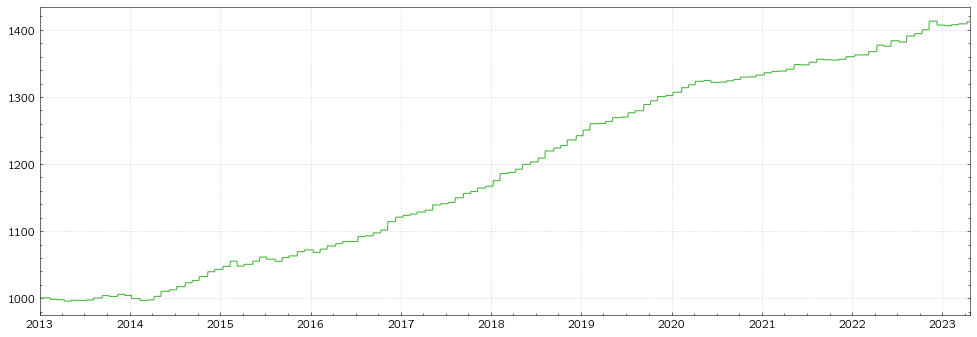

In [41]:
intraday_strategy.history().plot()

In [42]:
intraday_strategy.plot.timeline()

___

## Combining Strategies

In [43]:
basket = sig.BasketStrategy(
    constituent_names=[carry_strategy.name, intraday_strategy.name],
    weights=[0.5, 0.5],
    rebalance_frequency="3M",
    ticker="Simple Basket",
)

<AxesSubplot:>

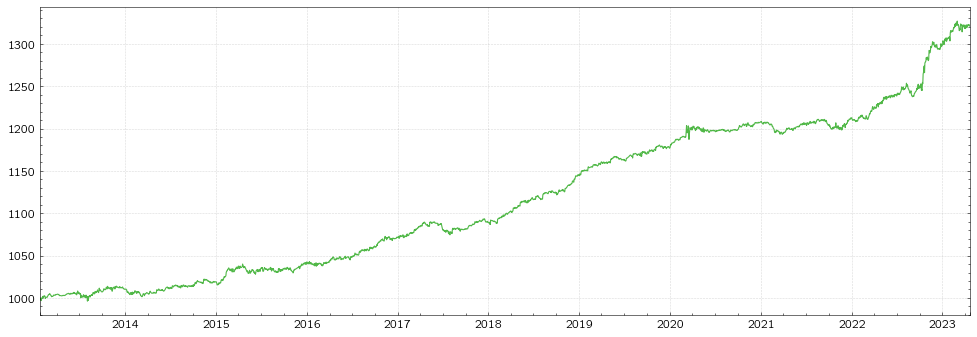

In [44]:
basket.history().plot()

In [45]:
basket.plot.tree(dtm.datetime(2023, 3, 18, 5))

,Strategy
,Position
,Cash
,Instrument Order
,Grouped Order
,Strategy Order
,FX Spot Order


### Optimization

In [46]:
combined_strategy_df = pd.DataFrame(
    {
        carry_strategy.name: carry_strategy.history(),
        intraday_strategy.name: intraday_strategy.history(),
    }
)
returns_df = combined_strategy_df.pct_change().dropna()

In [47]:
sig.Optimizer?

Init signature:
sig.Optimizer(
    factor_exposures: Optional[sigtech.framework.analytics.optimization.factor_exposure.FactorExposures] = None,
    optimization_problem: Optional[sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem] = None,
    factor_exposure_kwargs: Optional[dict] = None,
    cvx_kwargs: Optional[dict] = None,
    scipy_kwargs: Optional[dict] = None,
)
Docstring:     
A class implementing an optimisation task.

To run an optimisation problem, a ``OptimizationProblem`` object needs to be provided.

If fit requires Factors then the ``FactorExposures`` containing the data must also be passed and the weights are     found with ``Optimizer.calculate_optimized_weights``.
Otherwise, if the optimization does not require knowledge of factors, ``FactorExposures=None`` is valid but     ``calculate_optimized_weights_with_fit`` must be used.

.. seealso:: `sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem`

An example o

In [48]:
opt = sig.PortfolioOptimizer()
opt.prefer_mean_variance().require_fully_invested().calculate_weights(returns_df)

BOND FUTURES CARRY STRATEGY      -4.23176
BOND AUCTION INTRADAY STRATEGY    5.23176
dtype: float64

In [49]:
opt.prefer_equal_risk_contribution().require_fully_invested().calculate_weights(returns_df)

BOND FUTURES CARRY STRATEGY       0.290693
BOND AUCTION INTRADAY STRATEGY    0.709307
dtype: float64

In [50]:
po = sig.PortfolioOptimizer().prefer_inverse_vol_weighting().require_long_only().require_fully_invested()

optimized_strategy_inverse_vol = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 1),
    rebalance_frequency="EOM",
    signal_name=sig.signal_library.from_ts(combined_strategy_df).name,
    allocation_function=sig.signal_library.allocation.optimized_allocations,
    allocation_kwargs={
        "periods": 252,
        "optimization_frequency": "EOM",
        **po.signal_strategy_allocation_kwargs(),
    },
    ticker="Inverse Volatility Basket",
)

Optimizations:   0%|          | 0/123 [00:00<?, ?it/s]

<AxesSubplot:>

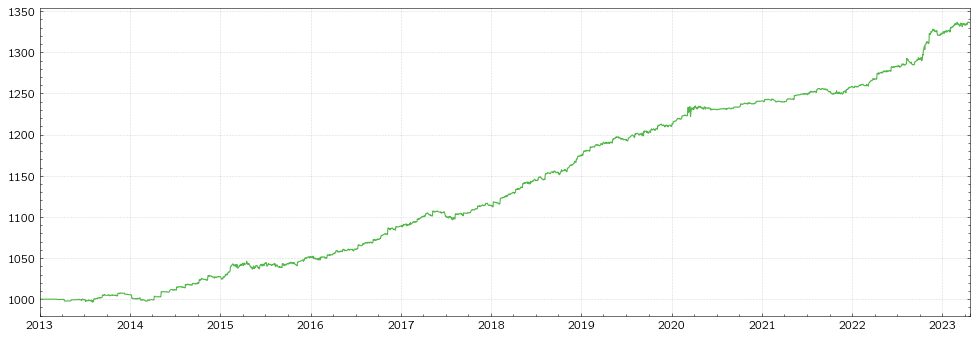

In [51]:
optimized_strategy_inverse_vol.history().plot()

In [52]:
optimized_strategy_inverse_vol.plot.portfolio_table()

___

## Performance and Analytics

,BOND FUTURES CARRY STRATEGY,BOND AUCTION INTRADAY STRATEGY,SIMPLE BASKET STRATEGY,INVERSE VOLATILITY BASKET STRATEGY
Annualised Excess Return,2.07%,3.41%,2.76%,2.85%
Annualised Standard Deviation,3.46%,1.41%,1.87%,1.40%
Annualised Sharpe Ratio (vs Cash),0.590,2.295,1.412,1.948
Annualised Sortino Ratio (vs Cash),0.995,8.698,2.544,4.089
Max Drawdown,-4.10%,-0.90%,-1.41%,-1.01%
Kurtosis,10.118,48.795,8.386,14.253
Skewness,0.396,5.887,0.577,1.878
Mean Positive Return,0.15%,0.37%,0.08%,0.06%
Mean Negative Return,-0.14%,-0.21%,-0.07%,-0.04%
Proportion Positive Returns,52.10%,3.87%,53.41%,54.37%


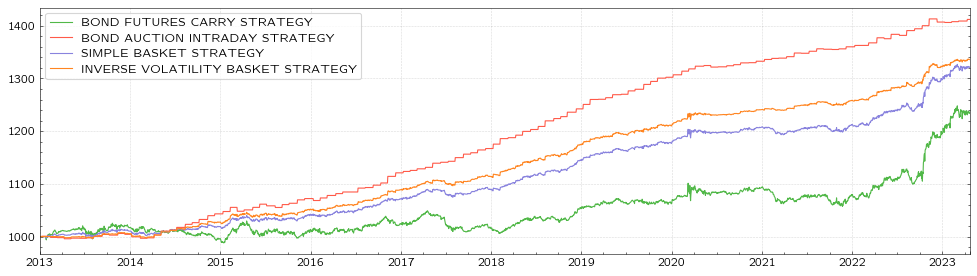

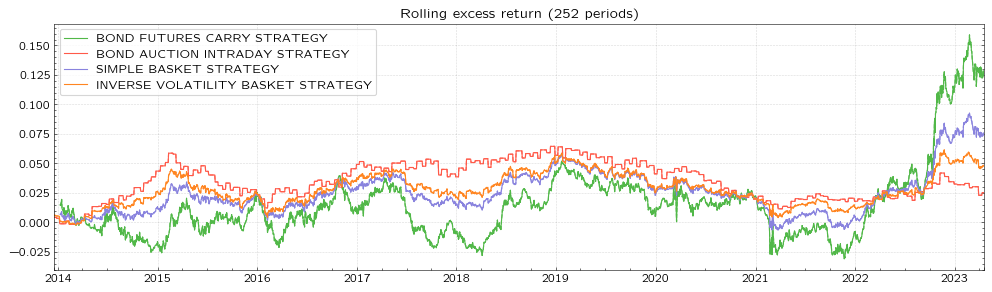

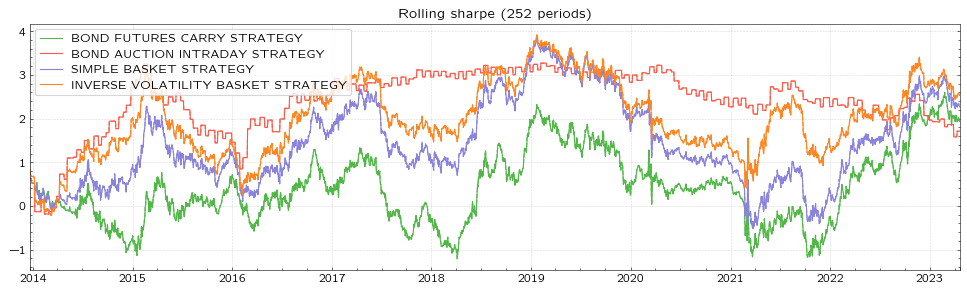

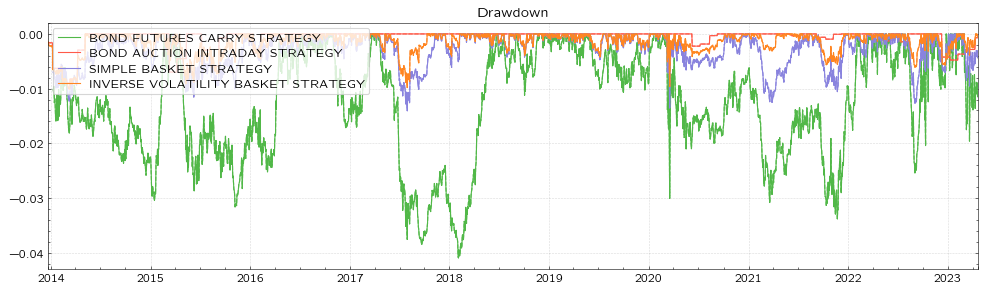

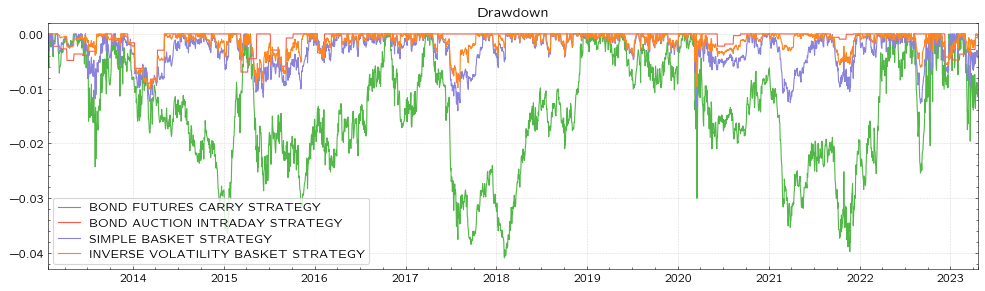

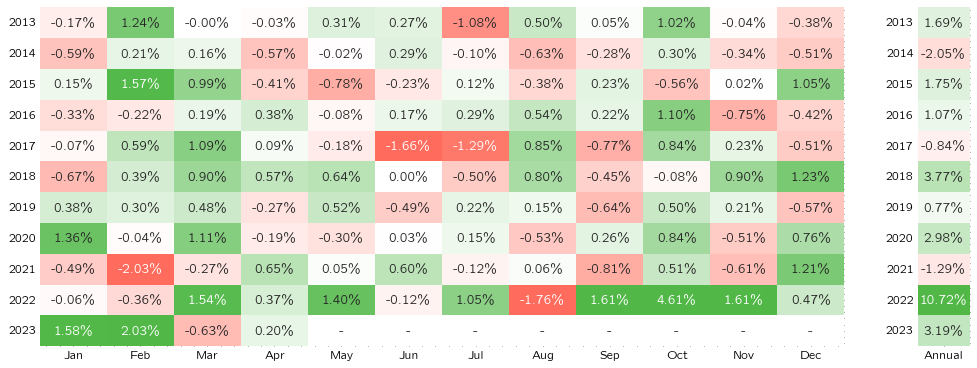

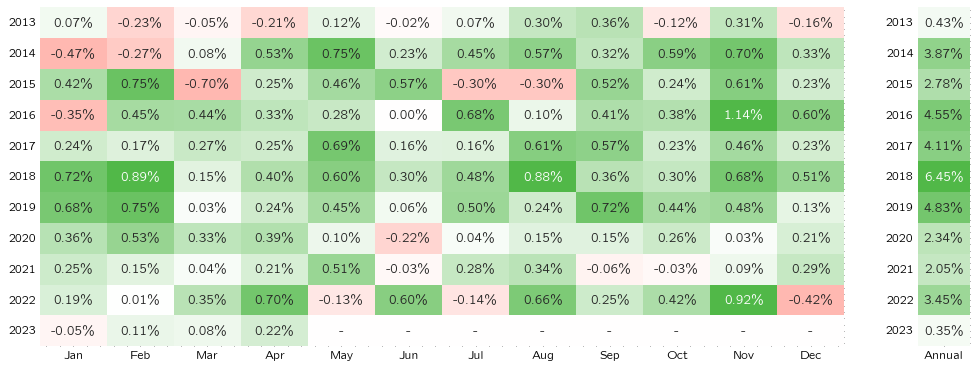

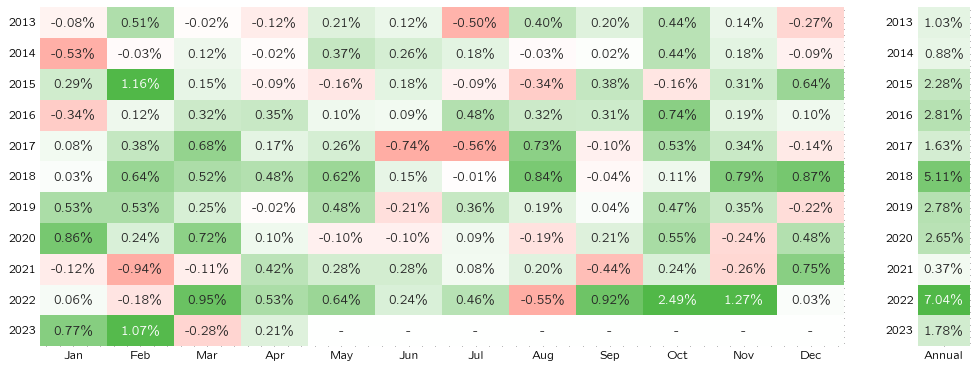

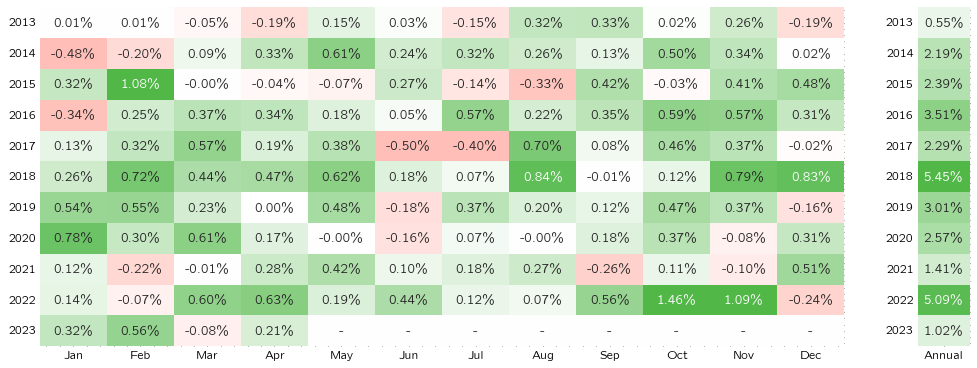

In [53]:
sig.PerformanceReport([carry_strategy, intraday_strategy, basket, optimized_strategy_inverse_vol]).report()